# PCHN63112 Workshop: Three-level Clustered Data Example
In this example,we will examine building a mixed-effects model for clustered data that contains three levels of variation. This will demonstrate how the multilevel framework extends beyond two levels, as well as how this can be integrated into a mixed-effects model.

## The Classroom Data
The data we will use concern measurements of improvement in maths ability in a selection of students from different classrooms across different schools. In total, these data contains measurements from 1,190 students from 312 classrooms from 107 schools. Importantly, these data were measured from first-graders in the USA (ages 6-7). As such, all students stay within the *same* classroom with the *same* teacher for the whole year. A wide variety of additional variables were captured describing the local area of the school, the teacher's experience and maths knowledge, and the student's demographic details. 

The data can be downloaded from [here](https://websites.umich.edu/~bwest/chapter4.html). Once downloaded to the current working directory, the code below will read the data into `R` and then print values for the first two classrooms from the first school

In [4]:
classroom <- read.csv('classroom.csv')
print(classroom[1:11,])

   sex minority mathkind mathgain   ses yearstea mathknow housepov mathprep
1    1        1      448       32  0.46        1       NA    0.082     2.00
2    0        1      460      109 -0.27        1       NA    0.082     2.00
3    1        1      511       56 -0.03        1       NA    0.082     2.00
4    0        1      449       83 -0.38        2    -0.11    0.082     3.25
5    0        1      425       53 -0.03        2    -0.11    0.082     3.25
6    1        1      450       65  0.76        2    -0.11    0.082     3.25
7    0        1      452       51 -0.03        2    -0.11    0.082     3.25
8    0        1      443       66  0.20        2    -0.11    0.082     3.25
9    1        1      422       88  0.64        2    -0.11    0.082     3.25
10   0        1      480       -7  0.13        2    -0.11    0.082     3.25
11   0        1      502       60  0.83        2    -0.11    0.082     3.25
   classid schoolid childid
1      160        1       1
2      160        1       2
3   

There are quite a few variables here, so we split them into those that relate to each *school* as a whole, each *classroom* as a whole and each *pupil* as a whole.

- School
    - `schoolid`: the unique index of each *school*
    - `housepov`: proportion of households in the local area below the poverty line
- Classroom
    - `classid`: the unique index of each *classroom*
    - `yearstea`: the teacher's years of experience
    - `mathprep`: the amount of training in mathematics education the teacher has undertaken
    - `mathknow`: the amount of mathematics knowledge the teacher has
- Student
    - `childid`: the unique index of each *student*
    - `mathgain`: **the student's gain in maths achievement over the year**
    - `sex`: the student's sex
    - `mathkind`: the student's maths score in the previous (kindergarten) year
    - `minority`: whether the student is from an ethnic minority background
    - `ses`: the student's socioeconomic status

Some of these variables are indices to keep things organised and to allow us to define different levels of the data: `schoolid`, `classid`, `childid`. The outcome variable is `mathgain`, highlighted in **bold**, indicative of how much the student has improved over the year spent in one particular classroom. This leaves *eight* potential predictor variables that could explain why some students improve more than others.

As these data are already long-formatted, we just need to convert the relevant variables to factors. We also choose to relabel both `sex` and `minority` to make their meaning clearer

In [6]:
classroom$classid  <- as.factor(classroom$classid)
classroom$schoolid <- as.factor(classroom$schoolid)
classroom$sex      <- as.factor(classroom$sex)
classroom$minority <- as.factor(classroom$minority)

levels(classroom$sex)      <- c('boy','girl')
levels(classroom$minority) <- c('nonminority', 'minority')

We can now briefly summarise all the variables. At this stage, we would usually produce some plots and do further data checking and wrangling, but we will leave this step to one side to keep the example shorter.

In [7]:
summary(classroom)

   sex             minority      mathkind        mathgain      
 boy :588   nonminority:384   Min.   :290.0   Min.   :-110.00  
 girl:602   minority   :806   1st Qu.:439.2   1st Qu.:  35.00  
                              Median :466.0   Median :  56.00  
                              Mean   :466.7   Mean   :  57.57  
                              3rd Qu.:495.0   3rd Qu.:  77.00  
                              Max.   :629.0   Max.   : 253.00  
                                                               
      ses              yearstea        mathknow          housepov     
 Min.   :-1.61000   Min.   : 0.00   Min.   :-2.5000   Min.   :0.0120  
 1st Qu.:-0.49000   1st Qu.: 4.00   1st Qu.:-0.7200   1st Qu.:0.0850  
 Median :-0.03000   Median :10.00   Median :-0.1300   Median :0.1270  
 Mean   :-0.01298   Mean   :12.21   Mean   : 0.0312   Mean   :0.1782  
 3rd Qu.: 0.39750   3rd Qu.:20.00   3rd Qu.: 0.8500   3rd Qu.:0.2550  
 Max.   : 3.21000   Max.   :40.00   Max.   : 2.6100   Max.   :

Some elements of note from these summaries:
- `sex` is balanced, so there is unlikely to be a bias here in terms of sex-related differences in attainment.
- `minority` indicates that the majority of the sample are from ethnic minority backgrounds ($806/(806+384) \times 100 = 67.73\%$).
- Some children have *negative* `mathgain` scores, indicating that they got *worse* over the year.
- There is a wide variation in `yearstea`, with some teachers having 40 years of experience and others having 0 years of teaching.
- There is also wide variation in `housepov`, with some school in area with very little poverty (1% of local houses) and some schools in areas with high poverty (56% of local houses).
- There are missing values in `mathknow`, as some teachers were not measured. 

### Model Notation
As these data are a mixture of *categorical* and *continuous* variables, a more general regression framework will be needed when writing this model. In what follows, we will use *descriptive labels* rather than greek letter for categorical variables (e.g. $\text{sex}_{j}$ rather than $\alpha_{j}$) and will introduce $\beta$-coefficients for continuous variables (e.g. $\beta_{1} \times \text{mathknow}_{i}$ rather than $\beta_{1}x_{i1}$). This should hopefully make it clearer which terms are categorical and which are continuous. In reality, the whole model is fit as a regression with dummy variables in place of the categorical predictors. However, it can be less clear to write the model this way, even if this is the reality of how it is fit.

## Data Structure
Although we already know what structure these data have, we will run through the logic for completeness.

Firstly, we need to determine our *unit of analysis*. In this example, our model is trying to explain improvements in maths scores in *students*. The entities that our model is describing are the *students* themselves, so these are our units of analysis.

Secondly, we determine what each *row* of the long-formatted data represents in relation to the units of analysis. Examining the first few rows

In [8]:
head(classroom)

   sex minority mathkind mathgain   ses yearstea mathknow housepov mathprep classid schoolid childid
1 girl minority      448       32  0.46        1       NA    0.082     2.00     160        1       1
2  boy minority      460      109 -0.27        1       NA    0.082     2.00     160        1       2
3 girl minority      511       56 -0.03        1       NA    0.082     2.00     160        1       3
4  boy minority      449       83 -0.38        2    -0.11    0.082     3.25     217        1       4
5  boy minority      425       53 -0.03        2    -0.11    0.082     3.25     217        1       5
6 girl minority      450       65  0.76        2    -0.11    0.082     3.25     217        1       6

we can see that each row corresponds to a single unit (*student*) measured *once*. So these are neither repeated measurements or longitudinal data. 

Finally, we need to determine whether there are any *clustering* variables that represent a higher-order dependency structure in these data. From what we can see above, there are several variables that are *constant* across multiple students: `yearstea`, `mathknow`, `housepov`, `mathprep`, `classid` and `schoolid`. Of those, only `classid` and `schoolid` are categorical and so are the only candidates for either *grouping variables* or *clustering variables*. 

In terms of thinking about clustering variables as representative of a *shared environment*, both `classid` and `schoolid` fit the description. These are both elements that each student is *IN* rather than something each student *HAS*. Students within a classroom may be correlated by virtue of sharing a teacher, sharing the same corpus of classmates and sharing the same teaching environment. Similarly, classrooms within a school may be correlated by virtue of sharing the same physical location, the same school budget and the same senior members of staff. The different schools represent the top boundary of dependence, because different schools will be independent of each other. Within a school, each classroom will have a degree of independence, as these are separate entities. However, they will also share a degree of dependence due to being within the same school. So this is a separate boundary of dependence. We imagine these as smaller covariance blocks within a larger covariance block.

Based on this, we can construct the following table of the *levels* of these data, using the guidance in the lesson

| **Data Type**    | **Clustered** | 
|------------------|---------------|
| **Dataset**      | `classroom`   |
| **Level 1**      | *Student*     |
| **Level 2**      | Classroom     |
| **Level 3**      | School        |

We could also imagine a more complex version of these data, where each student was measured at multiple points within a year. This would then be *longitudinal* clustered data with *four* levels. We would have the longitudinal measurements at Level 1, student at Level 2, classroom at Level 3 and school at Level 4. This would lead to quite a complex dependency structure that would be very difficult to reason about and build using a method like GLS. However, the mixed-effects framework allows us to build this carefully in layers, without every having to touch the covariance structure.

## Model Building
To build a model of this dataset, we use the 3-step procedure outlined in the lesson. We assume at this point that the data has been investigated, wrangled, cleaned and ready for modelling.

### Step I: A Single Dependency Structure
We start by isolating a single dependency structure. This needs to be at the *lowest* level, with no further dependency structures within. In this example, this is a single *classroom*. We choose `classid == '6'` for this purpose, after examining several candidates. This was chosen because it contains a reasonable number of measurements (5 students), has no missing data and has representation of *both* levels of `minority`. During this exploration, it was notable that many classrooms are *constant* in terms of `minority`, which will be important to bear in mind when building the model. 

In [32]:
classroom.1 <- subset(classroom, classid=='6')
print(classroom.1)

     sex    minority mathkind mathgain   ses yearstea mathknow housepov mathprep classid schoolid childid
251  boy    minority      431       36 -0.32        8    -0.12    0.187     3.75       6       21     251
252  boy    minority      454       23 -0.03        8    -0.12    0.187     3.75       6       21     252
253  boy nonminority      452       34  0.28        8    -0.12    0.187     3.75       6       21     253
254 girl    minority      448       44  0.31        8    -0.12    0.187     3.75       6       21     254
255 girl nonminority      405       60  0.33        8    -0.12    0.187     3.75       6       21     255


In terms of the variables suitable for an individual model of a single classroom, we note that many of the variables above are *constant* because they are defined either at the level of a classroom as a whole, or the school as a whole. As such, they are not suitable for modelling the individual students. We remove these below 

In [49]:
classroom.1 <- subset(classroom, classid=='6', select=c(-yearstea,-mathknow,-housepov,-mathprep,-classid,-schoolid))
print(classroom.1)

     sex    minority mathkind mathgain   ses childid
251  boy    minority      431       36 -0.32     251
252  boy    minority      454       23 -0.03     252
253  boy nonminority      452       34  0.28     253
254 girl    minority      448       44  0.31     254
255 girl nonminority      405       60  0.33     255


Based on this, our basic model for a single classroom is

$$
\text{mathgain}_{ijk} = \text{mean} + \text{sex}_{j} + \text{minority}_{k} + (\beta_{1} \times \text{mathkind}_{i}) + (\beta_{2} \times \text{ses}_{i}) + \eta_{ijk}
$$

where $i$ indexes the student, $j$ indexes `sex` and $k$ indexes `minority`. Both $\text{sex}_{j}$ and $\text{minority}_{k}$ are indicative of categorical effects, whereas $\text{mathkind}_{i}$ and $\text{ses}_{i}$ are indicative of continuous predictors with associated regression slopes $\beta_{1}$ and $\beta_{2}$.

If we attempt top fit this model, it will not work because we have *five* parameters and only *five* datapoints. There will be no variance left over and the fit will be perfect. We might think this is just a problem with the particular classroom we selected. However, the data are quite limited for most of the classrooms in this dataset. To see this, we use the code below to select 20 random classrooms and then plot them as panels with `sex` on the $x$-axis and different symbols used to indicate the levels of `minority`.

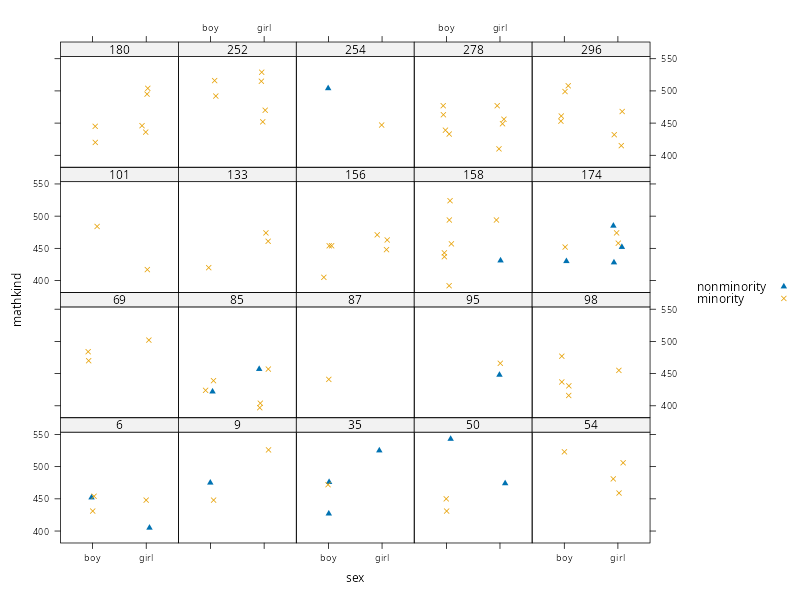

In [95]:
library('lattice')

set.seed(666)
keep.IDs <- sample(unique(classroom$classid), 20)      # select 20 random class IDs

xyplot(mathkind ~ sex | classid,                       # x-axis=sex, panels=classroom
  groups   = minority,                                 # minority different symbols
  data     = subset(classroom, classid %in% keep.IDs), # only random class IDs
  type     = "p",                                      # points (not joined)
  auto.key = TRUE,                                     # add key
  jitter.x = TRUE,                                     # jitter points for visibility
  par.settings = list(
    superpose.symbol = list(
      pch = c(17,4)                                    # symbols to triangle and cross
    )
  )
)

As we can see, some classrooms have much more data than others. However, in many of those cases there is only a single level of `minority` represented. Some classrooms only have a single student who was measured, whereas in others multiple students were measured but only of one `sex`. This suggests already that data will need be to pooled across classrooms in order to estimate the effects of `sex` and `minority`, precluding their inclusion as random per-classroom. We are jumping ahead slightly here, but this is all good information gathering to inform our later decisions.

### Step II: Expand to Multiple Structures
In our second step, we expand the model above to *multiple* classrooms. We index these using the notation of $(c)$, to indicate which terms *belong* to a particular *classroom*. We start with the most general case of allowing every term to vary by-classroom, giving us

$$
\text{mathgain}^{(c)}_{ijk} = \text{mean}^{(c)} + \text{sex}^{(c)}_{j} + \text{minority}^{(c)}_{k} + \left(\beta_{1}^{(c)} \times \text{mathkind}_{i}\right) + \left(\beta_{2}^{(c)} \times \text{ses}_{i}\right) + \eta^{(c)}_{ijk}
$$

We can now reason more carefully about all these terms.

$$
\begin{alignat*}{1}
\text{Level 1} \\
    \text{mathgain}^{(c)}_{ijk} &= \text{mean}^{(c)} + \text{sex}^{(c)}_{j} + \text{minority}^{(c)}_{k} + \eta^{(c)}_{ijk} \\ \quad \\
\text{Level 2} \\
    \text{mean}^{(c)}         &= \text{mean}^{(s)} + \xi^{(c)} \\
    \text{sex}^{(c)}_{j}      &=  \text{sex}^{(s)}_{j} + \xi_{j}^{(c)}\\ 
    \text{minority}^{(c)}_{k} &= \text{minority}^{(s)}_{k} + \xi_{k}^{(c)} \\ \quad \\
\text{Level 3} \\
    \text{mean}^{(s)}         &= \text{mean} + \xi^{(s)} \\
    \text{sex}^{(s)}_{j}      &=  \text{sex}_{j} + \xi_{j}^{(s)} \\ 
    \text{minority}^{(s)}_{k} &= \text{minority}_{k} + \xi_{k}^{(s)} \\ 
\end{alignat*}
$$